In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
plt.style.use('ggplot')

In [2]:
df = pd.read_csv("../data/raw/dat-ab-usos-2026.csv",encoding="latin1")

In [3]:
df.head()

,DIA_TRANSPORTE,NOMBRE_EMPRESA,LINEA,AMBA,TIPO_TRANSPORTE,JURISDICCION,PROVINCIA,MUNICIPIO,CANTIDAD,DATO_PRELIMINAR
0,2026-01-01,MUNICIPALIDAD DE MERCEDES PROVINCIA DE BUENOS ...,1,SI,COLECTIVO,MUNICIPAL,BUENOS AIRES,MERCEDES,138,NO
1,2026-01-01,MUNICIPALIDAD DE MERCEDES PROVINCIA DE BUENOS ...,2B,SI,COLECTIVO,MUNICIPAL,BUENOS AIRES,MERCEDES,69,NO
2,2026-01-01,EMPRESA BATAN S.A.,BS_AS_LINEA 715M,NO,COLECTIVO,MUNICIPAL,BUENOS AIRES,GENERAL PUEYRREDON,1572,NO
3,2026-01-01,EMPRESA BATAN S.A.,BS_AS_LINEA 720M,NO,COLECTIVO,MUNICIPAL,BUENOS AIRES,GENERAL PUEYRREDON,475,NO
4,2026-01-01,COMPAÃIAÂ DE TRANSPORTE VECINAL S.A.,BS_AS_LINEA_326,SI,COLECTIVO,PROVINCIAL,BUENOS AIRES,SN,97,NO


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 177411 entries, 0 to 177410
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   DIA_TRANSPORTE   177411 non-null  str  
 1   NOMBRE_EMPRESA   177411 non-null  str  
 2   LINEA            177411 non-null  str  
 3   AMBA             177411 non-null  str  
 4   TIPO_TRANSPORTE  177411 non-null  str  
 5   JURISDICCION     176578 non-null  str  
 6   PROVINCIA        176578 non-null  str  
 7   MUNICIPIO        176578 non-null  str  
 8   CANTIDAD         177411 non-null  int64
 9   DATO_PRELIMINAR  177411 non-null  str  
dtypes: int64(1), str(9)
memory usage: 13.5 MB


In [5]:
df.columns

Index(['DIA_TRANSPORTE', 'NOMBRE_EMPRESA', 'LINEA', 'AMBA', 'TIPO_TRANSPORTE',
       'JURISDICCION', 'PROVINCIA', 'MUNICIPIO', 'CANTIDAD',
       'DATO_PRELIMINAR'],
      dtype='str')

El dataset contiene 149.339 registros y 10 variables relacionadas con el uso del sistema SUBE.

La variable CANTIDAD representa el número de transacciones y se encuentra en formato numérico, lo cual facilita el análisis.

La columna DIA_TRANSPORTE está en formato texto y deberá convertirse a tipo fecha para permitir análisis temporales.

Se detectan valores nulos en las variables JURISDICCION, PROVINCIA y MUNICIPIO, posiblemente asociados a ciertos tipos de transporte como subte.

In [6]:
df['DIA_TRANSPORTE'] = pd.to_datetime(df['DIA_TRANSPORTE'])
df['DIA_TRANSPORTE'].dtype

dtype('<M8[us]')

In [7]:
df_viajes_diarios = df.groupby('DIA_TRANSPORTE', as_index=False)['CANTIDAD'].sum()
df_viajes_diarios.info()

<class 'pandas.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   DIA_TRANSPORTE  119 non-null    datetime64[us]
 1   CANTIDAD        119 non-null    int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 2.0 KB


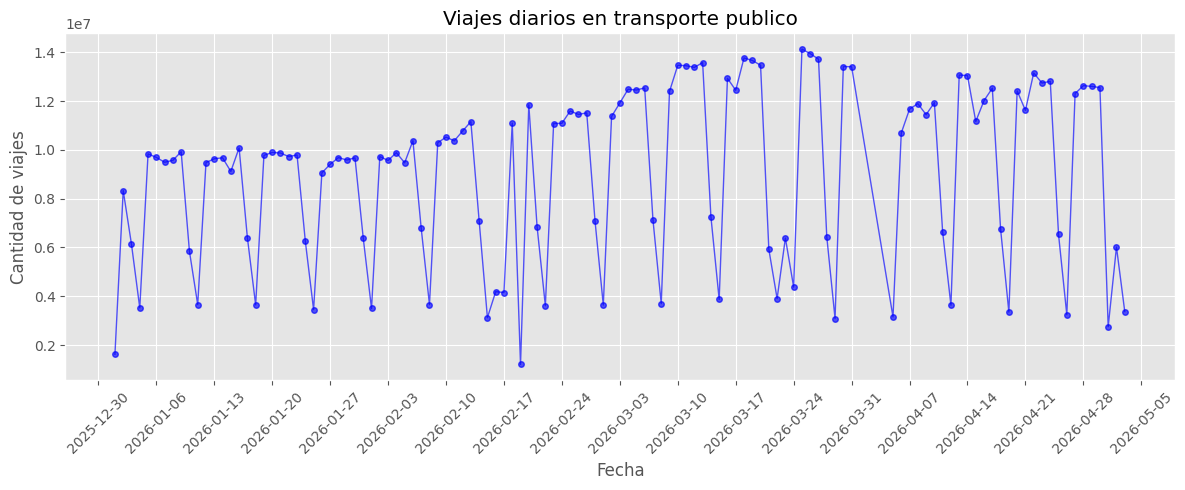

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_viajes_diarios['DIA_TRANSPORTE'], df_viajes_diarios['CANTIDAD'],color='blue',alpha=0.65,marker='o', markersize=4, linewidth=1)
ax.set_title('Viajes diarios en transporte publico')
ax.set_xlabel('Fecha')
ax.set_ylabel('Cantidad de viajes')
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
# Establecer el inicio del eje x en 26-12-2025
start_date = pd.to_datetime('2025-12-26')
ax.set_xlim(left=start_date)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Pareciera verse que en los días de semana hay más de 10 millones transacciones, mientras que en fines de semana estas bajan a 4 millones. 

Además, pareciera que a medida que avanza el año, se realizan más transacciones en los días de semana.

Por último, se notan períodos que rompen con el patrón semanal, como en la semana del 16/02/26, 

Exploremos más esta información.

In [9]:
dias_semana = {
    0: 'lunes',
    1: 'martes',
    2: 'miercoles',
    3: 'jueves',
    4: 'viernes',
    5: 'sabado',
    6: 'domingo'
}

df_viajes_diarios['dia'] = df_viajes_diarios['DIA_TRANSPORTE'].dt.dayofweek.map(dias_semana)
df_viajes_diarios.head()

,DIA_TRANSPORTE,CANTIDAD,dia
0,2026-01-01,1621473,jueves
1,2026-01-02,8332677,viernes
2,2026-01-03,6126432,sabado
3,2026-01-04,3524089,domingo
4,2026-01-05,9836834,lunes


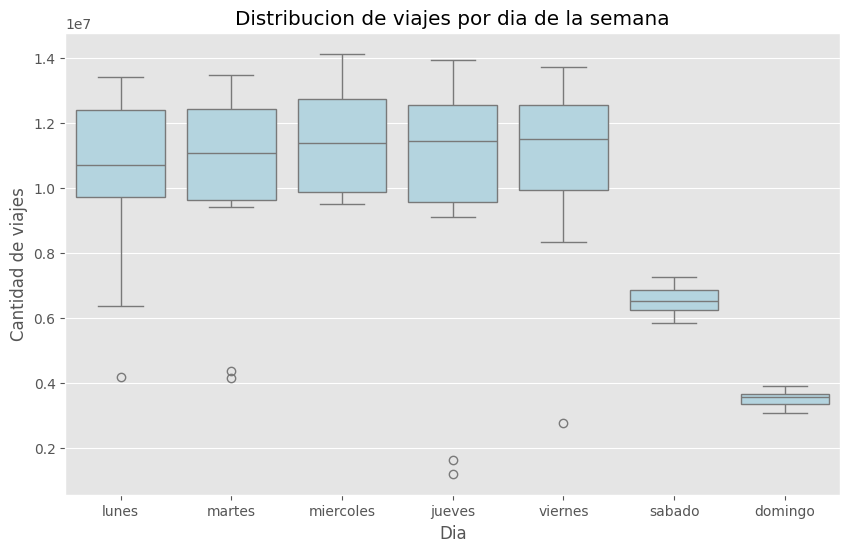

In [10]:
orden_dias = ['lunes', 'martes', 'miercoles', 'jueves', 'viernes', 'sabado', 'domingo']

plt.figure(figsize=(10, 6))
sns.boxplot(x='dia', y='CANTIDAD', data=df_viajes_diarios, order=orden_dias,color='lightblue')

plt.title('Distribucion de viajes por dia de la semana')
plt.xlabel('Dia')
plt.ylabel('Cantidad de viajes')
#plt.xticks(rotation=45)
plt.show()


Se puede ver entonces que en los días de semana se suelen realizar entre 8 y 14 millones de transacciones, mientras que los sábados se realizan entre 6 y 8 millones, y los domingos alrededor de 4 millones.

Cabe destacar también que hay mayor variación los días lunes, y que en los domingos hay muy poca.

Además, aparecen algunos datos atípicos en los días lunes, martes y especialmente jueves.

In [11]:
df_tipos = df.groupby(['DIA_TRANSPORTE', 'TIPO_TRANSPORTE'], as_index=False)['CANTIDAD'].sum()
df_tipos.head()

,DIA_TRANSPORTE,TIPO_TRANSPORTE,CANTIDAD
0,2026-01-01,COLECTIVO,1500635
1,2026-01-01,LANCHAS,714
2,2026-01-01,SUBTE,47160
3,2026-01-01,TREN,72964
4,2026-01-02,COLECTIVO,7329711


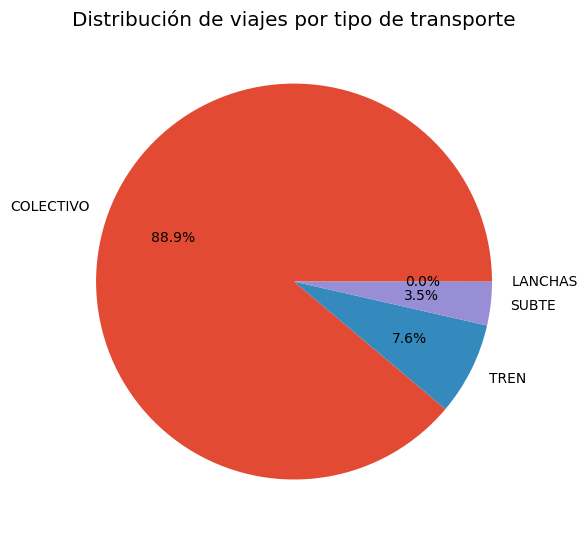

In [12]:
df_tipos_total = df_tipos.groupby('TIPO_TRANSPORTE')['CANTIDAD'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(df_tipos_total.values, labels=df_tipos_total.index, autopct='%1.1f%%', startangle=0,labeldistance=1.1,pctdistance=0.65)
ax.set_title('Distribución de viajes por tipo de transporte')
plt.tight_layout()
plt.show()

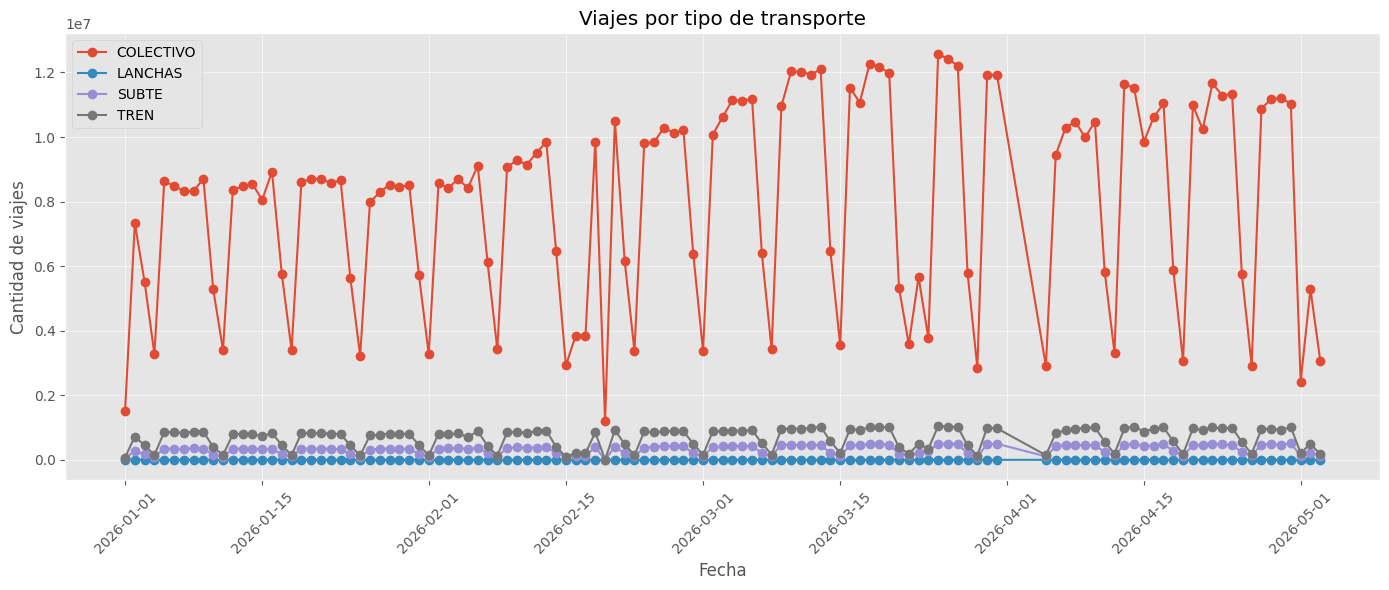

In [13]:
fig, ax = plt.subplots(figsize=(14, 6))

for tipo in df_tipos['TIPO_TRANSPORTE'].unique():
    data = df_tipos[df_tipos['TIPO_TRANSPORTE'] == tipo]
    ax.plot(data['DIA_TRANSPORTE'], data['CANTIDAD'], label=tipo, marker='o')

ax.set_xlabel('Fecha')
ax.set_ylabel('Cantidad de viajes')
ax.set_title('Viajes por tipo de transporte')
ax.legend(loc='best')
ax.grid(True, alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

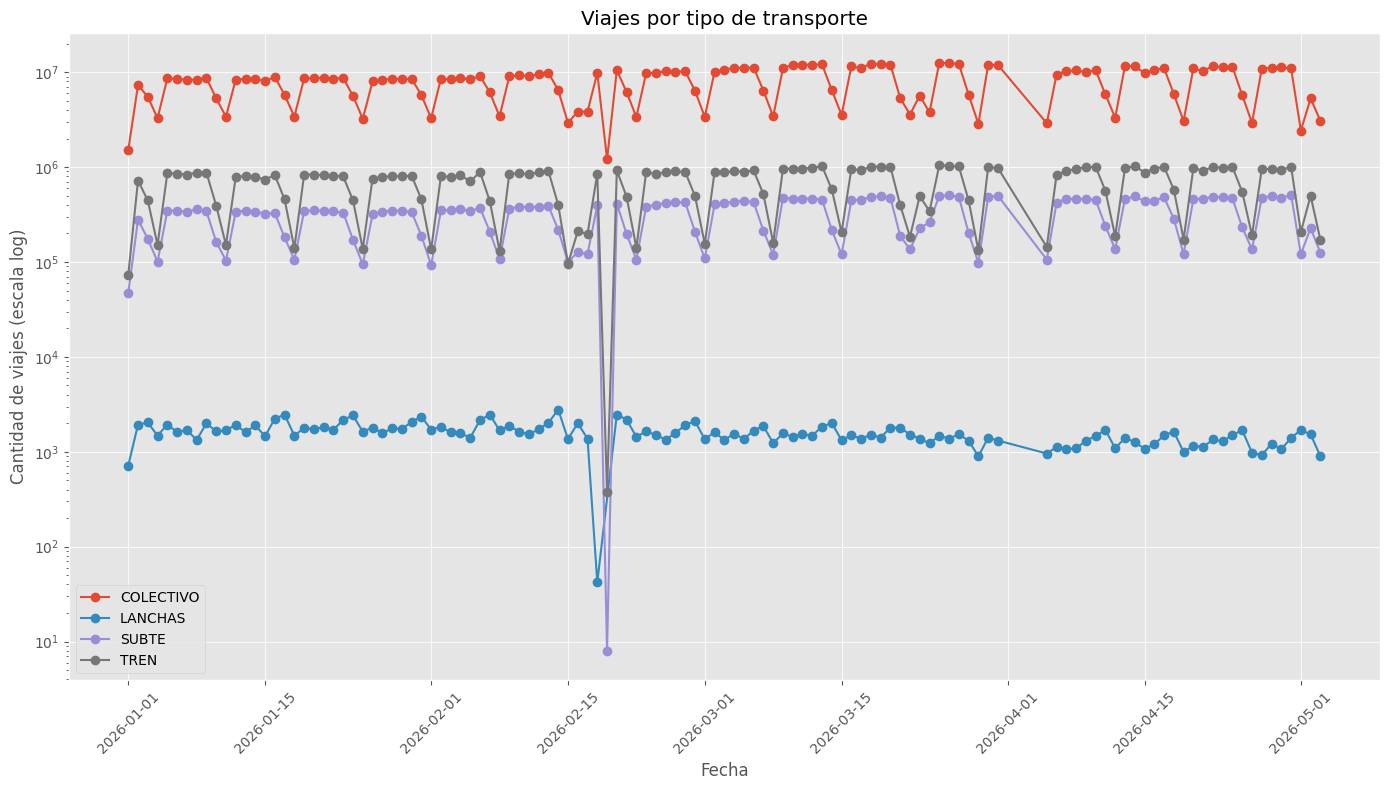

In [15]:
fig, ax = plt.subplots(figsize=(14, 8))

for tipo in df_tipos['TIPO_TRANSPORTE'].unique():
    data = df_tipos[df_tipos['TIPO_TRANSPORTE'] == tipo]
    ax.plot(data['DIA_TRANSPORTE'], data['CANTIDAD'], label=tipo, marker='o')

ax.set_yscale('log')
ax.set_xlabel('Fecha')
ax.set_ylabel('Cantidad de viajes (escala log)')
ax.set_title('Viajes por tipo de transporte')
ax.legend(loc='best')
ax.grid(True, alpha=0.8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
df_tipos_promedio = df_tipos.groupby('TIPO_TRANSPORTE')['CANTIDAD'].mean()
df_tipos_promedio

TIPO_TRANSPORTE
COLECTIVO    8.040075e+06
LANCHAS      1.569695e+03
SUBTE        3.211746e+05
TREN         6.861421e+05
Name: CANTIDAD, dtype: float64

Se puede ver que todos los tipos de transporte mantienen la cantidad de viajes estable durante los días de semana, y disminuyen los fines de semana.  

Además, se puede ver que el medio de transporte más utilizado es el colectivo, rondando las 8 millones de transacciones diarias. Seguido por el tren, con cerca de 700.000 transacciones diarias. Luego está el subte, con 300.000 transacciones diarias, y por último la lancha, con un promedio de 1.500 transacciones diarias. 

En conclusión, el sistema de transporte se sostiene principalmente por los colectivos, complementando con trenes y subtes, y marginalmente utilizando lanchas.

Quiero detenerme en el outlier del 19/02/2026 porque es demasiado notorio. Este se debe a un paro general de transporte, que incluyó colectivos, trenes y subtes en todo el país. Además el día anterior se efectuó un paro nacional de actividades marítimas y fluviales, que redujeron el uso de lanchas. Veamos estos días con más detalle.

In [24]:
print(df_viajes_diarios[df_viajes_diarios['DIA_TRANSPORTE'] == pd.to_datetime('2026-02-19')]['CANTIDAD'].values[0])

1207402


Es decir, que el 19-02-2026 se realizaron sólamente 1,2 millones de transacciones, reduciendo un 90% la movilidad por transporte público.

Una pregunta que me hago es: cuáles fueron las lineas que se mantuvieron andando este día?